To begin, let's take a look at the training dataset and the terminology. 
- `koi` stands for Kepler Objects of Interest, essentially exoplanet candidates.
- `koi_disposition` classifies KOIs as either a CANDIDATE, FALSE POSITIVE, or CONFIRMED

We want to clean through the provided dataset and purely focus on KOIs that are confirmed exoplanets.


In [8]:
import pandas as pd

# Store the .csv file as a 'DataFrame' data type (provided by the pandas library)
df = pd.read_csv('../data/cumulative.csv')

# Count all of the values found in the 'koi_disposition' column
df['koi_disposition'].value_counts()

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

We can clearly see the three types of KOI dispositions:
- `FALSE POSITIVE`
- `CONFIRMED`
- `CANDIDATE`

What we know is true is either the `FALSE POSITIVE` or the `CONFIRMED` disposition and this is what we need to train our scikit-learn model. Let's drop the `CANDIDATE` column now and convert this to be a binary label column for easier use.

In [10]:
# Remove the 'CANDIDATE' column via filtering
df = df[df['koi_disposition'] != 'CANDIDATE']

# Creates a new column if it did not exist before, where if the 'koi_disposition' is 'CONFIRMED', then it's a 1, otherwise its a 0
df['label'] = (df['koi_disposition'] == 'CONFIRMED').astype(int)

# Testing
print(df['label'].value_counts())

label
0    5023
1    2293
Name: count, dtype: int64


Now that we've filtered the DataFrame for either `CONFIRMED` or `FALSE POSITIVES`, we will also need to check for any rows with missing values. This will be important later

In [20]:

# Find values within the columns that are null and shows the first 20 columns
# Raw values:
print(df.isnull().sum().sort_values(ascending=False).head(20))

koi_teq_err2         7316
koi_teq_err1         7316
kepler_name          5022
koi_score            1059
koi_steff_err2        412
koi_srad_err1         397
koi_slogg_err2        397
koi_srad_err2         397
koi_steff_err1        397
koi_slogg_err1        397
koi_depth_err2        377
koi_time0bk_err1      377
koi_time0bk_err2      377
koi_period_err1       377
koi_impact_err1       377
koi_duration_err1     377
koi_impact_err2       377
koi_depth_err1        377
koi_period_err2       377
koi_duration_err2     377
dtype: int64


In [24]:
# Percentage:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(20)

koi_teq_err2         100.000000
koi_teq_err1         100.000000
kepler_name           68.644068
koi_score             14.475123
koi_steff_err2         5.631493
koi_srad_err1          5.426463
koi_slogg_err2         5.426463
koi_srad_err2          5.426463
koi_steff_err1         5.426463
koi_slogg_err1         5.426463
koi_depth_err2         5.153089
koi_time0bk_err1       5.153089
koi_time0bk_err2       5.153089
koi_period_err1        5.153089
koi_impact_err1        5.153089
koi_duration_err1      5.153089
koi_impact_err2        5.153089
koi_depth_err1         5.153089
koi_period_err2        5.153089
koi_duration_err2      5.153089
dtype: float64

Let's also take a statistical overview of the dataset's key features too.

In [25]:
key_features = ['koi_period', 'koi_depth', 'koi_duration',
                'koi_prad', 'koi_teq', 'koi_impact',
                'koi_steff', 'koi_slogg', 'koi_srad']

df[key_features].describe()

,koi_period,koi_depth,koi_duration,koi_prad,koi_teq,koi_impact,koi_steff,koi_slogg,koi_srad
count,7316.000000,7.016000e+03,7316.000000,7016.000000,7016.000000,7016.000000,7016.000000,7016.000000,7016.000000
mean,58.816738,3.062011e+04,5.865646,129.973917,1148.595639,0.796773,5727.706813,4.303516,1.779288
std,121.082398,9.287398e+04,6.965178,3519.623953,898.326612,3.668625,825.221536,0.444626,6.203126
min,0.241843,8.000000e-01,0.104600,0.080000,92.000000,0.000000,2661.000000,0.047000,0.116000
25%,2.237412,1.845500e+02,2.527525,1.520000,559.000000,0.224000,5320.000000,4.206750,0.829000
50%,8.507657,5.074500e+02,3.904750,2.680000,928.000000,0.576000,5779.500000,4.438000,1.000000
75%,36.184630,2.775100e+03,6.432175,25.450000,1496.250000,0.916250,6126.000000,4.543000,1.367000
max,1071.232624,1.541400e+06,138.540000,200346.000000,14667.000000,100.806000,15896.000000,5.283000,229.908000


Let's visualize this to get a better sense of what these numbers mean

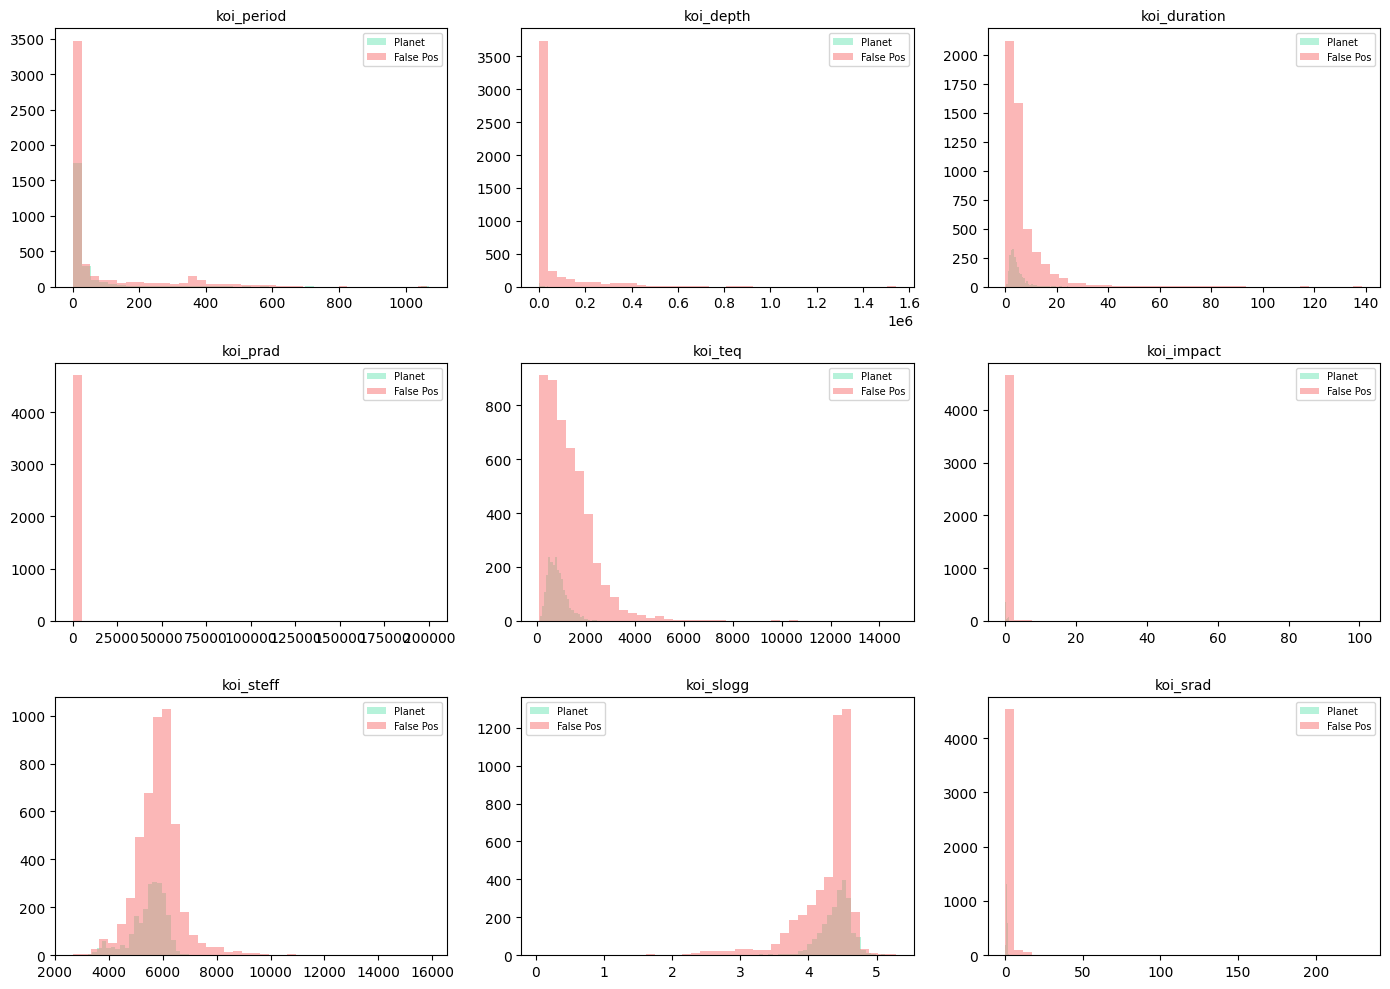

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), key_features):
    for label, color in [(1, '#6ee7b7'), (0, '#f87171')]:
        subset = df[df['label'] == label]
        ax.hist(subset[col].dropna(), bins=40, alpha=0.5,
                color=color, label='Planet' if label else 'False Pos')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('../notebook/eda_distributions.png', dpi=150)
plt.show()

Right now, we can take note of how `koi_period`, `koi_depth`, `koi_prad`, `koi_duration`, and `koi_srad` are heavily skewed to the left. The histograms are just generally hard to interpret what's going on because of the outliers; outliers compress the data such that the data is hard to view and interpret. Outliers will also mess up our classifier model too, so they will need to be dealt with